DEDUPLICATION

In [ ]:

import pandas as pd
import ipywidgets as widgets
from google.colab import files, drive
import io
import os

# 1. Mount Google Drive with a "Force" option to avoid the ValueError
try:
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully.")
except Exception as e:
    print(f"Mounting failed or already mounted: {e}")

# Define the folder path correctly for Colab
folder_path = '/content/drive/MyDrive/scraping'

# Create the 'scraping' folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created new folder: {folder_path}")
else:
    print(f"Folder already exists: {folder_path}")

# 2. Upload Files
print("Upload your files (e.g., data_set.xlsx):")
uploaded = files.upload()

# 3. UI Elements
file_names = list(uploaded.keys())
if not file_names:
    print("No files uploaded. Please run the cell again.")
else:
    dropdown = widgets.Dropdown(options=file_names, description='Select File:')
    button = widgets.Button(description="Process & Save", button_style='success')
    output = widgets.Output()

    def process_data(b):
        with output:
            output.clear_output()
            filename = dropdown.value

            # Load Data
            try:
                if filename.endswith('.xlsx'):
                    df = pd.read_excel(io.BytesIO(uploaded[filename]))
                else:
                    df = pd.read_csv(io.BytesIO(uploaded[filename]))

                # Logic: Unique combination of Position AND Text
                if 'Position' in df.columns and 'FULL_TEXT_CORPUS' in df.columns:
                    initial_rows = len(df)

                    # Sorting keeps things in order before dropping
                    df = df.sort_values(by='Position')

                    # This drops ONLY if Position and Text are exactly the same
                    df_cleaned = df.drop_duplicates(subset=['Position', 'FULL_TEXT_CORPUS'], keep='first')

                    final_rows = len(df_cleaned)

                    # Save to Google Drive
                    save_path = os.path.join(folder_path, f"cleaned_{filename}")

                    # Ensure saving as .xlsx
                    if not save_path.endswith('.xlsx'):
                        save_path += '.xlsx'

                    df_cleaned.to_excel(save_path, index=False)

                    print(f"✅ Process Complete!")
                    print(f"Original rows: {initial_rows} | New rows: {final_rows}")
                    print(f"Removed {initial_rows - final_rows} duplicate rows.")
                    print(f"📁 File saved to Drive in the 'scraping' folder.")
                else:
                    print("❌ Error: Missing 'Position' or 'FULL_TEXT_CORPUS' columns.")
            except Exception as err:
                print(f"An error occurred during processing: {err}")

    button.on_click(process_data)
    display(dropdown, button, output)

Mounted at /content/drive
Drive mounted successfully.
Folder already exists: /content/drive/MyDrive/scraping
Upload your files (e.g., data_set.xlsx):


Saving unfiltered_doc final.xlsx to unfiltered_doc final.xlsx


Dropdown(description='Select File:', options=('unfiltered_doc final.xlsx',), value='unfiltered_doc final.xlsx'…

Button(button_style='success', description='Process & Save', style=ButtonStyle())

Output()

INTIAL CLEANING

In [ ]:
import pandas as pd
import re
import os
import ipywidgets as widgets
from google.colab import drive
from IPython.display import display


# 2. Get list of Excel files in the 'scraping' folder
file_list = [f for f in os.listdir(folder_path) if f.endswith(('.xlsx', '.csv'))]

if not file_list:
    print(f"No files found in {folder_path}. Please put your file there first.")
else:
    # Create Dropdown for file selection
    file_dropdown = widgets.Dropdown(
        options=file_list,
        description='Select File:',
        style={'description_width': 'initial'}
    )

    process_button = widgets.Button(description="Start Initial Cleaning", button_style='primary')
    output = widgets.Output()

    display(file_dropdown, process_button, output)

# 3. CLEANING FUNCTION (Optimized for your requirements)
def initial_clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase everything
    text = text.lower()

    # A. PROTECT "covid-19"
    text = re.sub(r'covid-19', 'COVIDTOKEN', text)

    # B. Remove URLs and DOI links
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'doi:\s*\S+', '', text)

    # C. Remove Citations in brackets [1] or [10, 33]
    text = re.sub(r'\[.*?\]', '', text)

    # D. REMOVE ALL PUNCTUATION AND NUMBERS
    # We replace everything that's NOT a lowercase letter or space with a space
    text = re.sub(r'[^a-z\s]', ' ', text)

    # E. RESTORE "covid-19"
    text = re.sub(r'COVIDTOKEN', 'covid-19', text)

    # F. Remove extra whitespaces
    text = " ".join(text.split())

    return text

# 4. Processing Logic
def on_button_clicked(b):
    with output:
        output.clear_output()
        selected_file = file_dropdown.value
        input_path = os.path.join(folder_path, selected_file)

        print(f"Reading: {selected_file}...")
        if selected_file.endswith('.xlsx'):
            df = pd.read_excel(input_path)
        else:
            df = pd.read_csv(input_path)

        if 'FULL_TEXT_CORPUS' not in df.columns:
            print("Error: Column 'FULL_TEXT_CORPUS' not found in this file!")
            return

        print("Cleaning text... (Removing punctuation/numbers, keeping 'covid-19')")
        df['CLEANED_TEXT'] = df['FULL_TEXT_CORPUS'].apply(initial_clean_text)

        # 5. Saving to Drive
        save_name = "INITIAL CLEANED DOC.xlsx"
        save_path = os.path.join(folder_path, save_name)
        df.to_excel(save_path, index=False)

        print(f"✅ Process Complete!")
        print(f"File saved to Drive as: {save_path}")
        display(df[['Position', 'CLEANED_TEXT']].head())

process_button.on_click(on_button_clicked)

Dropdown(description='Select File:', options=('cleaned_data_set.xlsx', 'cleaned_data_set (1).xlsx', 'INITIAL C…

Button(button_style='primary', description='Start Initial Cleaning', style=ButtonStyle())

Output()

In [ ]:
import os

folder_path = "/content/drive/MyDrive/scraping/"
print(os.listdir(folder_path))

['cleaned_data_set.xlsx', 'cleaned_data_set (1).xlsx', 'INITIAL CLEANED DOC.xlsx', 'TOKENIZED DOC.xlsx', 'STOPWORDS REMOVED DOC.xlsx', 'FINAL PREPROCESSED DOC.xlsx', 'cleaned_unfiltered_doc final.xlsx']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
===== Measures of Dispersion (Document Lengths) =====
Mean: 3567.09
Standard Deviation: 1356.05
Variance: 1838884.74
Range: 6052

Min Length: 25
Max Length: 6077


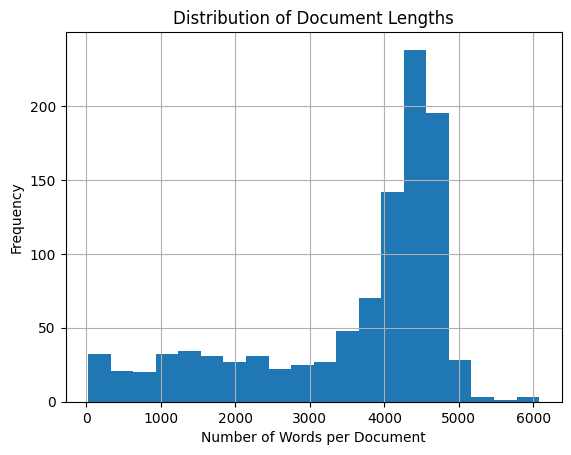

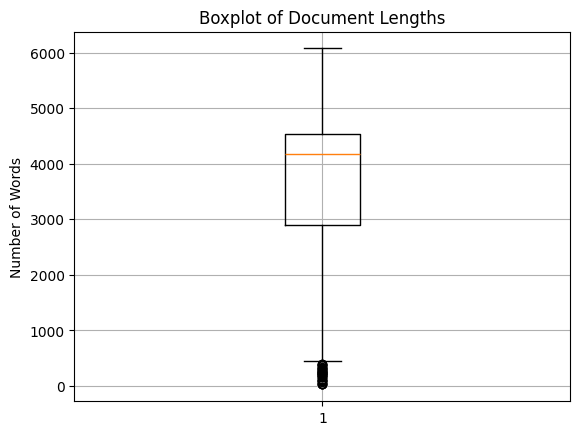

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# ===================== MEASURES OF DISPERSION =====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. LOAD DATA ----
file_path = "/content/drive/MyDrive/scraping/INITIAL CLEANED DOC.xlsx"
df = pd.read_excel(file_path)

# ---- 2. EXTRACT TEXT COLUMN ----
texts = df['CLEANED_TEXT'].dropna()

# Convert to tokens (split words)
texts = [str(doc).split() for doc in texts]

# ---- 3. DOCUMENT LENGTHS ----
doc_lengths = [len(text) for text in texts]

# ---- 4. DISPERSION METRICS ----
mean_len = np.mean(doc_lengths)
std_len = np.std(doc_lengths)
var_len = np.var(doc_lengths)
range_len = np.max(doc_lengths) - np.min(doc_lengths)

print("===== Measures of Dispersion (Document Lengths) =====")
print(f"Mean: {mean_len:.2f}")
print(f"Standard Deviation: {std_len:.2f}")
print(f"Variance: {var_len:.2f}")
print(f"Range: {range_len}")

print("\nMin Length:", np.min(doc_lengths))
print("Max Length:", np.max(doc_lengths))

# ---- 5. HISTOGRAM ----
plt.figure()
plt.hist(doc_lengths, bins=20)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words per Document")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# ---- 6. BOXPLOT ----
plt.figure()
plt.boxplot(doc_lengths)
plt.title("Boxplot of Document Lengths")
plt.ylabel("Number of Words")
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# FIX: GET TEXTS FROM DATAFRAME
# Change 'processed_text' to your actual column name
texts = df['processed_text']

# If your data is stored as strings, convert to tokens
texts = [str(doc).split() for doc in texts]

# ---- 1. DOCUMENT LENGTHS ----
doc_lengths = [len(text) for text in texts]

# ---- 2. DISPERSION METRICS ----
mean_len = np.mean(doc_lengths)
std_len = np.std(doc_lengths)
var_len = np.var(doc_lengths)
range_len = np.max(doc_lengths) - np.min(doc_lengths)

print("===== Measures of Dispersion (Document Lengths) =====")
print(f"Mean: {mean_len:.2f}")
print(f"Standard Deviation: {std_len:.2f}")
print(f"Variance: {var_len:.2f}")
print(f"Range: {range_len}")

# ---- 3. HISTOGRAM ----
plt.figure()
plt.hist(doc_lengths, bins=20)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words per Document")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# ---- 4. BOXPLOT ----
plt.figure()
plt.boxplot(doc_lengths)
plt.title("Boxplot of Document Lengths")
plt.ylabel("Number of Words")
plt.grid()
plt.show()

# ---- 5. EXTRA ----
print("\nMin Length:", np.min(doc_lengths))
print("Max Length:", np.max(doc_lengths))

TOKENAZATION

In [ ]:
import pandas as pd
import os
import ipywidgets as widgets
from google.colab import drive
from IPython.display import display
import nltk
from nltk.tokenize import word_tokenize

# --- FIX: Download both required resources ---
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/scraping'

# 2. Selection UI
file_list = [f for f in os.listdir(folder_path) if "INITIAL CLEANED" in f]

if not file_list:
    print(f"No cleaned files found in {folder_path}. Please run the cleaning code first.")
else:
    file_dropdown = widgets.Dropdown(options=file_list, description='Select Cleaned File:')
    token_button = widgets.Button(description="Run Tokenization", button_style='info')
    output = widgets.Output()
    display(file_dropdown, token_button, output)

# 3. Tokenization Logic
def run_tokenization(b):
    with output:
        output.clear_output()
        selected_file = file_dropdown.value
        input_path = os.path.join(folder_path, selected_file)

        print(f"Reading: {selected_file}...")
        df = pd.read_excel(input_path)

        if 'CLEANED_TEXT' not in df.columns:
            print("Error: 'CLEANED_TEXT' column not found.")
            return

        print("Tokenizing text...")

        def safe_tokenize(text):
            try:
                # Standard NLTK tokenization
                return word_tokenize(str(text))
            except Exception:
                # Fallback: simple split if NLTK fails
                return str(text).split()

        df['TOKENS'] = df['CLEANED_TEXT'].apply(safe_tokenize)

        # 4. Save to Drive
        save_name = "TOKENIZED DOC.xlsx"
        save_path = os.path.join(folder_path, save_name)

        # Convert list to string for Excel saving
        df_to_save = df.copy()
        df_to_save['TOKENS'] = df_to_save['TOKENS'].apply(lambda x: str(x))
        df_to_save.to_excel(save_path, index=False)

        print(f"✅ Tokenization Complete!")
        print(f"File saved as: {save_name}")

        # Display Preview
        print("\nPreview of first 10 tokens:")
        display(df[['Position', 'TOKENS']].head())

token_button.on_click(run_tokenization)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


Dropdown(description='Select Cleaned File:', options=('INITIAL CLEANED DOC.xlsx',), value='INITIAL CLEANED DOC…

Button(button_style='info', description='Run Tokenization', style=ButtonStyle())

Output()

STOP WORD REMOVAL

In [ ]:
import pandas as pd
import os
import re
import ipywidgets as widgets
from google.colab import drive
from IPython.display import display
import nltk
from nltk.corpus import stopwords

# Download the standard stopword list
nltk.download('stopwords')

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/scraping'

# 2. Selection UI
file_list = [f for f in os.listdir(folder_path) if "TOKENIZED" in f]

if not file_list:
    print(f"No tokenized files found. Please run the tokenization code first.")
else:
    file_dropdown = widgets.Dropdown(options=file_list, description='Select Tokenized File:')
    stop_button = widgets.Button(description="Remove Custom Stop Words", button_style='warning')
    output = widgets.Output()
    display(file_dropdown, stop_button, output)

# 3. Robust Logic for filtering
def run_stopword_removal(b):
    with output:
        output.clear_output()
        selected_file = file_dropdown.value
        input_path = os.path.join(folder_path, selected_file)

        print(f"Reading: {selected_file}...")
        df = pd.read_excel(input_path)

        # SAFE LOADER: Extracts words even if Excel truncated the string
        def safe_get_tokens(text):
            if not isinstance(text, str): return []
            # Extract anything that looks like a word inside the quotes
            return re.findall(r"'(.*?)'", text)

        print("Converting tokens...")
        df['TOKENS_LIST'] = df['TOKENS'].apply(safe_get_tokens)

        # --- YOUR MASSIVE CUSTOM STOP WORD LIST ---
        # (Cleaned and combined for efficiency)
        custom_list = [
            "study", "studies", "research", "data", "participants", "reported", "found", "results",
            "analysis", "sample", "survey", "online", "scale", "measures", "used", "using",
            "associated", "conducted", "review", "method", "methods", "questionnaire", "respondents",
            "evidence", "literature", "findings", "table", "figure", "page", "doi", "org", "http",
            "https", "www", "etal", "article", "journal", "university", "publication", "author",
            "authors", "editor", "publisher", "volume", "issue", "appendix", "mean", "scores",
            "score", "variables", "total", "model", "regression", "significant", "correlation",
            "p-value", "health", "mental", "covid", "pandemic", "impact", "coronavirus", "disease",
            "illness", "related", "during", "outbreak", "crisis", "situation", "sars", "cov", "viral",
            "infection", "high", "higher", "lower", "low", "levels", "increased", "factors", "general",
            "time", "people", "well", "age", "group", "groups", "cases", "individuals", "public",
            "life", "including", "negative", "positive", "increase", "current", "many", "period",
            "level", "various", "likely", "possible", "potential", "difference", "compared",
            "population", "estimate", "coefficient", "interval", "standard", "deviation",
            "significance", "dummy", "coded", "bin", "non", "link", "scholar", "abstract",
            "position", "kzn", "tzr", "sokws", "the", "and", "for", "with", "that", "were", "was",
            "this", "from", "are", "not", "their", "more", "may", "who", "has", "all", "between",
            "which", "also", "these", "other", "among", "had", "been", "can", "than", "such",
            "about", "they", "one", "those", "there", "our", "due", "most", "but", "after", "will",
            "some", "first", "each", "when", "only", "however", "while", "over", "could", "through",
            "any", "before", "should", "out", "its", "did", "less", "very", "even", "have", "number",
            "included", "both", "based", "effects", "information", "two"
        ]

        stop_words = set(stopwords.words('english'))
        stop_words.update([w.lower() for w in custom_list])

        print(f"Filtering tokens...")
        # Apply filter: Remove stop words AND words that are too short
        df['FILTERED_TOKENS'] = df['TOKENS_LIST'].apply(
            lambda x: [word for word in x if word.lower() not in stop_words and len(word) > 2]
        )

        # 4. Save to Drive
        save_name = "STOPWORDS REMOVED DOC.xlsx"
        save_path = os.path.join(folder_path, save_name)

        # Convert list back to string, but we'll use a simpler comma format to save space
        df_to_save = df.drop(columns=['TOKENS', 'TOKENS_LIST'])
        df_to_save['FILTERED_TOKENS'] = df_to_save['FILTERED_TOKENS'].apply(lambda x: ",".join(x))
        df_to_save.to_excel(save_path, index=False)

        print(f"✅ Success! Filtered tokens saved as: {save_name}")
        display(df_to_save[['Position', 'FILTERED_TOKENS']].head())

stop_button.on_click(run_stopword_removal)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mounted at /content/drive


Dropdown(description='Select Tokenized File:', options=('TOKENIZED DOC.xlsx',), value='TOKENIZED DOC.xlsx')

Button(button_style='warning', description='Remove Custom Stop Words', style=ButtonStyle())

Output()


Lemmatization

In [ ]:
import pandas as pd
import os
import ipywidgets as widgets
from google.colab import drive
from IPython.display import display
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download required dictionaries
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/scraping'

# 2. Selection UI
file_list = [f for f in os.listdir(folder_path) if "STOPWORDS REMOVED" in f]

if not file_list:
    print(f"No filtered files found. Please run the stopword removal code first.")
else:
    file_dropdown = widgets.Dropdown(options=file_list, description='Select File:')
    lem_button = widgets.Button(description="Run Aggressive Lemmatization", button_style='success')
    output = widgets.Output()
    display(file_dropdown, lem_button, output)

# Helper function to map NLTK POS tags to WordNet tags
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

# 3. Lemmatization Logic
def run_aggressive_lemmatization(b):
    with output:
        output.clear_output()
        selected_file = file_dropdown.value
        input_path = os.path.join(folder_path, selected_file)

        print(f"Reading: {selected_file}...")
        df = pd.read_excel(input_path)

        # Convert back to list
        df['TEMP_LIST'] = df['FILTERED_TOKENS'].apply(lambda x: str(x).split(',') if isinstance(x, str) else [])

        lemmatizer = WordNetLemmatizer()

        print("Running Aggressive Lemmatization (Verb + Noun checking)...")

        # This version checks if the word is a verb to ensure "published" -> "publish"
        def aggressive_lem(word_list):
            return [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in word_list]

        df['LEMMATIZED_TOKENS'] = df['TEMP_LIST'].apply(aggressive_lem)

        # 4. Save the FINAL PREPROCESSED document
        save_name = "FINAL PREPROCESSED DOC.xlsx"
        save_path = os.path.join(folder_path, save_name)

        df_to_save = df.copy()
        df_to_save['LEMMATIZED_TOKENS'] = df_to_save['LEMMATIZED_TOKENS'].apply(lambda x: ",".join(x))
        df_to_save = df_to_save.drop(columns=['TEMP_LIST'])
        df_to_save.to_excel(save_path, index=False)

        print(f"✅ Success! 'published' should now be 'publish'.")
        print(f"File saved as: {save_name}")


lem_button.on_click(run_aggressive_lemmatization)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Mounted at /content/drive


Dropdown(description='Select File:', options=('STOPWORDS REMOVED DOC.xlsx',), value='STOPWORDS REMOVED DOC.xls…

Button(button_style='success', description='Run Aggressive Lemmatization', style=ButtonStyle())

Output()

EDA

Mounted at /content/drive
------------------------------
📊 DATASET SUMMARY STATISTICS
Total Documents: 1030
Total Tokens: 1475729
Unique Vocabulary Size: 86923
Average Words per Document: 1438.61
------------------------------


/tmp/ipykernel_260/1717282681.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[0, 0], palette='viridis')


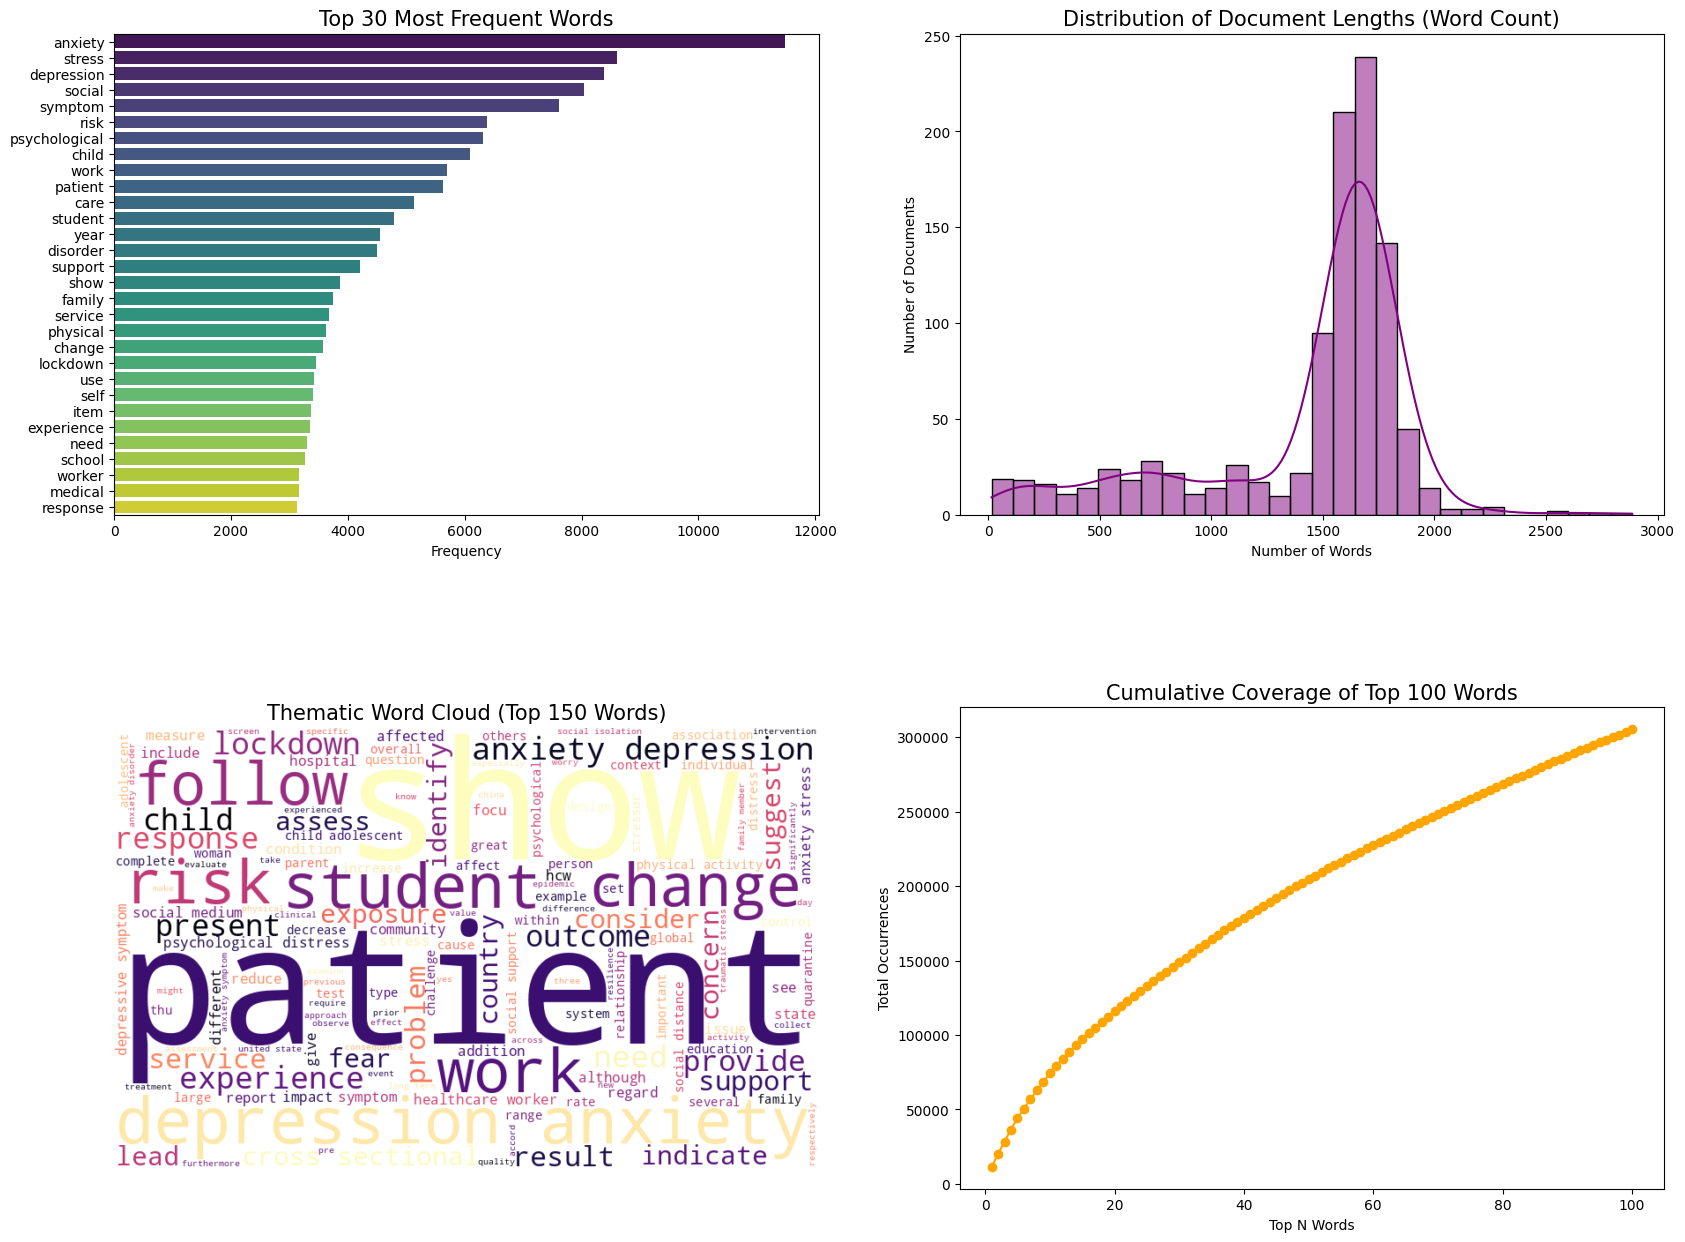

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import os
from google.colab import drive

# 1. Mount Drive and Setup
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/scraping'
file_name = "FINAL PREPROCESSED DOC.xlsx"
file_path = os.path.join(folder_path, file_name)

def run_robust_eda():
    if not os.path.exists(file_path):
        print(f"❌ Error: {file_name} not found in {folder_path}. Please run previous steps.")
        return

    # 2. Load and Clean data for analysis
    df = pd.read_excel(file_path)

    # Ensure column exists and handle missing values
    if 'LEMMATIZED_TOKENS' not in df.columns:
        print("❌ Error: 'LEMMATIZED_TOKENS' column not found.")
        return

    # Drop rows where tokens are missing or empty
    df = df.dropna(subset=['LEMMATIZED_TOKENS'])

    # Convert string-stored tokens back to lists
    tokens_list = df['LEMMATIZED_TOKENS'].apply(lambda x: str(x).split(','))

    # 3. Calculate Statistics
    doc_lengths = tokens_list.apply(len)
    all_words = [word for sublist in tokens_list for word in sublist if len(word) > 2]
    word_freq = Counter(all_words)
    unique_words_count = len(word_freq)

    print("-" * 30)
    print("📊 DATASET SUMMARY STATISTICS")
    print(f"Total Documents: {len(df)}")
    print(f"Total Tokens: {len(all_words)}")
    print(f"Unique Vocabulary Size: {unique_words_count}")
    print(f"Average Words per Document: {doc_lengths.mean():.2f}")
    print("-" * 30)

    # 4. Create Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    plt.subplots_adjust(hspace=0.4)

    # --- Plot A: Top 30 Most Frequent Words ---
    common_words = word_freq.most_common(30)
    words, counts = zip(*common_words)
    sns.barplot(x=list(counts), y=list(words), ax=axes[0, 0], palette='viridis')
    axes[0, 0].set_title("Top 30 Most Frequent Words", fontsize=15)
    axes[0, 0].set_xlabel("Frequency")

    # --- Plot B: Document Length Distribution ---
    sns.histplot(doc_lengths, bins=30, kde=True, ax=axes[0, 1], color='purple')
    axes[0, 1].set_title("Distribution of Document Lengths (Word Count)", fontsize=15)
    axes[0, 1].set_xlabel("Number of Words")
    axes[0, 1].set_ylabel("Number of Documents")

    # --- Plot C: Word Cloud ---
    wc = WordCloud(width=800, height=500, background_color='white',
                   colormap='magma', max_words=150).generate(" ".join(all_words))
    axes[1, 0].imshow(wc, interpolation='bilinear')
    axes[1, 0].axis('off')
    axes[1, 0].set_title("Thematic Word Cloud (Top 150 Words)", fontsize=15)

    # --- Plot D: Cumulative Coverage (Checking Sparsity) ---
    sorted_counts = sorted(word_freq.values(), reverse=True)
    cumulative_sum = [sum(sorted_counts[:i]) for i in range(1, 101)]
    axes[1, 1].plot(range(1, 101), cumulative_sum, marker='o', color='orange')
    axes[1, 1].set_title("Cumulative Coverage of Top 100 Words", fontsize=15)
    axes[1, 1].set_xlabel("Top N Words")
    axes[1, 1].set_ylabel("Total Occurrences")

    plt.show()

# Run the function
run_robust_eda()

FEATURE ENGINEERING

In [ ]:
!pip install gensim openpyxl nltk -q


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_excel("/content/drive/MyDrive/scraping/FINAL PREPROCESSED DOC.xlsx")

print("Rows:", df.shape[0])
df.head()


Rows: 1030


,Query,Position,Title,Authors,Journal,Publication Info,Year,Citations,Abstract,PDF Link,Scholar Link,DOI,FULL_TEXT_CORPUS,CLEANED_TEXT,FILTERED_TOKENS,LEMMATIZED_TOKENS
0,Impact of covid 19 on mental health,2,The COVID‐19 pandemic and mental health impacts,"K Usher, J Durkin, N Bhullar",… journal of mental health nursing,"… journal of mental health nursing, 2020 - pmc...",2020.0,995,"… novel coronavirus, COVID-19, was first repor...",https://pmc.ncbi.nlm.nih.gov/articles/PMC72621...,https://pmc.ncbi.nlm.nih.gov/articles/PMC7262128/,NaN,editorial Int J Ment Health Nurs . 2020 Apr 10...,editorial int j ment health nurs apr the covid...,"editorial,int,ment,nurs,apr,impacts,kim,usher,...","editorial,int,ment,nurs,apr,impact,kim,usher,k..."
1,Impact of covid 19 on mental health,4,Impact of COVID-19 pandemic on mental health,J Heitzman,Psychiatr Pol,"Psychiatr Pol, 2020 - scholar.archive.org",2020.0,273,"… , the symptomatic spectrum of mental disorde...",https://scholar.archive.org/work/clvic3iwoff4l...,https://scholar.archive.org/work/clvic3iwoff4l...,NaN,You've reached the limit for the number of req...,you ve reached the limit for the number of req...,"reached,limit,requests,made,short,please,wait,...","reach,limit,request,make,short,please,wait,mom..."
2,Impact of covid 19 on mental health,6,The impact of the COVID-19 pandemic on the men...,"F Ornell, SC Halpern, FHP Kessler…",Cadernos de saude …,"Cadernos de saude …, 2020 - SciELO Public Health",2020.0,601,… psychological responses and associated facto...,NaN,https://www.scielosp.org/article/csp/2020.v36n...,NaN,The 2019 novel coronavirus pandemic (COVID-19)...,the novel coronavirus pandemic is an internati...,"novel,international,emergency,unprecedented,mo...","novel,international,emergency,unprecedented,mo..."
3,Impact of covid 19 on mental health,7,Mental health and the COVID-19 pandemic,"B Gavin, J Lyne, F McNicholas",Irish journal of psychological …,"Irish journal of psychological …, 2020 - cambr...",2020.0,215,… to mental health and the COVID-19 … COVID-19...,https://www.cambridge.org/core/services/aop-ca...,https://www.cambridge.org/core/journals/irish-...,NaN,Mental health and the COVID-19 pandemic B. Gav...,mental health and the pandemic b gavin j lyne ...,"gavin,lyne,mcnicholas,department,child,adolesc...","gavin,lyne,mcnicholas,department,child,adolesc..."
4,Impact of covid 19 on mental health,9,The mental health impact of the COVID-19 pande...,"KS Khan, MA Mamun, MD Griffiths, I Ullah",… journal of mental health and …,"… journal of mental health and …, 2022 - Springer",2022.0,501,… These mental health and emotional issues are...,https://link.springer.com/content/pdf/10.1007/...,https://link.springer.com/article/10.1007/s114...,NaN,LETTER TO THE EDITOR The Mental Health Impact ...,letter to the editor the mental health impact ...,"letter,across,different,cohorts,kiran,shafiq,k...","letter,across,different,cohort,kiran,shafiq,kh..."


In [ ]:

# STEP 1: FEATURE ENGINEERING FOR LDA



# 0. Install gensim (if needed)
!pip install gensim


# 1. Import libraries
import pandas as pd
import os
import pickle
from gensim.models.phrases import Phrases, Phraser
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from google.colab import drive

# 2. Load dataset
df = pd.read_excel("/content/drive/MyDrive/scraping/FINAL PREPROCESSED DOC.xlsx")

print("Dataset shape:", df.shape)
print("Columns:", df.columns)


# 3. Extract tokens

texts = df["LEMMATIZED_TOKENS"].dropna().apply(
    lambda x: [w.strip() for w in str(x).split(",") if w.strip() != ""]
).tolist()

print("\nExample tokens BEFORE bigrams:")
print(texts[0][:20])


# 4. Build Bigram Model

bigram_model = Phrases(
    texts,
    min_count=5,     # appear in at least 5 documents
    threshold=10     # higher = fewer phrases
)

bigram_phraser = Phraser(bigram_model)

texts_bigrams = [bigram_phraser[doc] for doc in texts]

print("\nExample tokens AFTER bigrams:")
print(texts_bigrams[0][:20])


# 5. Create Dictionary

dictionary = Dictionary(texts_bigrams)

dictionary.filter_extremes(
    no_below=5,     # remove rare words
    no_above=0.5    # remove overly common words
)

print("\nDictionary size:", len(dictionary))


# 6. Create Bag-of-Words Corpus

corpus_bow = [dictionary.doc2bow(doc) for doc in texts_bigrams]

print("\nExample Bag-of-Words:")
print(corpus_bow[0][:10])


# 7. Apply TF-IDF (Optional)

tfidf_model = TfidfModel(corpus_bow)
corpus_tfidf = list(tfidf_model[corpus_bow])

print("\nExample TF-IDF:")
print(corpus_tfidf[0][:10])


# 8. Save Outputs to Drive

drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/LDA_Project/"
os.makedirs(save_path, exist_ok=True)

# Save dictionary
dictionary.save(save_path + "lda_dictionary.gensim")

# Save Bag-of-Words
with open(save_path + "lda_corpus_bow.pkl", "wb") as f:
    pickle.dump(corpus_bow, f)

# Save TF-IDF
with open(save_path + "lda_corpus_tfidf.pkl", "wb") as f:
    pickle.dump(corpus_tfidf, f)

# Save bigram texts
with open(save_path + "lda_texts_bigrams.pkl", "wb") as f:
    pickle.dump(texts_bigrams, f)

print("\n✅ STEP 1 COMPLETE AND SAVED TO DRIVE")
print("Saved in:", save_path)

Dataset shape: (1030, 16)
Columns: Index(['Query', 'Position', 'Title', 'Authors', 'Journal', 'Publication Info',
       'Year', 'Citations', 'Abstract', 'PDF Link', 'Scholar Link', 'DOI',
       'FULL_TEXT_CORPUS', 'CLEANED_TEXT', 'FILTERED_TOKENS',
       'LEMMATIZED_TOKENS'],
      dtype='object')

Example tokens BEFORE bigrams:
['editorial', 'int', 'ment', 'nurs', 'apr', 'impact', 'kim', 'usher', 'kim', 'usher', 'dipapph', 'nsg', 'mnst', 'phd', 'facmhn', 'school', 'new', 'england', 'armidale', 'new']

Example tokens AFTER bigrams:
['editorial', 'int_ment', 'nurs', 'apr', 'impact', 'kim', 'usher', 'kim', 'usher', 'dipapph', 'nsg', 'mnst', 'phd', 'facmhn', 'school', 'new_england', 'armidale', 'new_south', 'wale_australia', 'find_article']

Dictionary size: 18225

Example Bag-of-Words:
[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 3), (6, 1), (7, 1), (8, 2), (9, 1)]

Example TF-IDF:
[(0, np.float64(0.01356782328213356)), (1, np.float64(0.02142417703937002)), (2, np.float64(0.0130150665

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# STEP 2: OPTIMIZED LDA & COHERENCE

import pickle
import os
from google.colab import drive
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

# 1. Mount Drive
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# 2. Load Step 1 Outputs
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

print("Data loaded successfully!")
print("Dictionary size:", len(dictionary))
print("Number of documents:", len(corpus_bow))

# 3. Train Multiple LDA Models (Reduced Range)
coherence_scores = []
topic_range = range(1,5)

for num_topics in topic_range:

    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=5,
        chunksize=200,
        alpha='auto',
        per_word_topics=False
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts_bigrams,
        dictionary=dictionary,
        coherence='c_v',
        processes=2,
        topn=10
    )

    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

    print(f"Topics: {num_topics} | Coherence: {coherence:.4f}")

# 4. Plot Coherence Scores
plt.figure()
plt.plot(topic_range, coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimized LDA Topic Coherence")
plt.show()

# 5. Select Best Topic Number
best_index = coherence_scores.index(max(coherence_scores))
best_num_topics = topic_range[best_index]

print("\nBest Number of Topics:", best_num_topics)
print("Best Coherence Score:", max(coherence_scores))

# 6. Train Final LDA Model (Stronger Settings)
final_lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=20,
    chunksize=200,
    alpha='auto',
    eta='auto'
)

# 7. Save Final Model
final_lda_model.save(load_path + "final_lda_model.gensim")

print("\n✅ COMPLETE: Final LDA Model Saved")

In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.4 MB/s eta 0:00:00


In [ ]:
!pip install gensim pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.1 MB/s eta 0:00:00


In [ ]:
# STEP 3: TOPIC INTERPRETATION & ANALYSIS

import pickle
import pandas as pd
from google.colab import drive
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Mount Drive
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# Load components
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

final_lda_model = LdaModel.load(load_path + "final_lda_model.gensim")

print("✅ Model and data loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and data loaded successfully


In [ ]:

# 1. Extract Top 15 Words per Topic

num_words = 15

for topic_id in range(final_lda_model.num_topics):
    print(f"\nTopic {topic_id}")
    words = final_lda_model.show_topic(topic_id, topn=num_words)
    print(", ".join([word for word, prob in words]))


Topic 0
fear, dierent, make_available, version_post, preprint, international_license, funder_grant, medrxiv_license, display_preprint, holder_preprint, frontier_psychology, peer_copyright, perpetuity_certify, region, gender

Topic 1
objective_evaluate, depressive_episode, crude_odds, percentage_reduction, briefed, probabilistic_snowball, conep, lodge, cochrane_library, awide, sudden_unexpected, antigen, soqkm, hubei_china, radius

Topic 2
fountoulakis, thessaloniki_greece, objective_evaluate, depressive_episode, crude_odds, percentage_reduction, briefed, probabilistic_snowball, conep, lodge, cochrane_library, awide, sudden_unexpected, antigen, soqkm

Topic 3
hcws, burnout, worker, perceive_stress, healthcare_worker, professional, physician, hospital, medical, moderate, unit, item, others, staff, job

Topic 4
ptsd, china, prevalence, anxiety_depression, quarantine, post_traumatic, insomnia, trauma, cross_sectional, epidemic, stress_disorder, ptsd_symptom, survivor, meta, sleep

Topic 5

In [ ]:

# 2. Document-Topic Distribution


doc_topics = []

for doc in corpus_bow:
    topic_probs = final_lda_model.get_document_topics(doc)
    doc_topics.append(topic_probs)

# Convert to dataframe
topic_df = pd.DataFrame()

for i in range(final_lda_model.num_topics):
    topic_df[f"Topic_{i}"] = [
        dict(doc).get(i, 0) for doc in doc_topics
    ]

topic_df.tail()

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_25,Topic_26,Topic_27,Topic_28,Topic_29,Topic_30,Topic_31,Topic_32,Topic_33,Topic_34
1025,0.000000,0,0.0,0.5764,0.000000,0.0,0.162087,0.0,0.037655,0.082786,...,0,0.0,0.0,0.112503,0.0,0.014729,0.000000,0.0,0.000000,0.000000
1026,0.000000,0,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.223487,0.000000
1027,0.000000,0,0.0,0.0000,0.018162,0.0,0.000000,0.0,0.032625,0.000000,...,0,0.0,0.0,0.000000,0.0,0.583758,0.313417,0.0,0.000000,0.000000
1028,0.597397,0,0.0,0.0000,0.054777,0.0,0.000000,0.0,0.060591,0.011300,...,0,0.0,0.0,0.091219,0.0,0.172803,0.000000,0.0,0.000000,0.000000
1029,0.000000,0,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.208622,0.013573,...,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.042521


In [ ]:

# 2. Document-Topic Distribution


doc_topics = []

for doc in corpus_bow:
    topic_probs = final_lda_model.get_document_topics(doc)
    doc_topics.append(topic_probs)

# Convert to dataframe
topic_df = pd.DataFrame()

for i in range(final_lda_model.num_topics):
    topic_df[f"Topic_{i}"] = [
        dict(doc).get(i, 0) for doc in doc_topics
    ]

topic_df.tail()

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_25,Topic_26,Topic_27,Topic_28,Topic_29,Topic_30,Topic_31,Topic_32,Topic_33,Topic_34
1025,0.000000,0,0.0,0.5764,0.000000,0.0,0.162087,0.0,0.037655,0.082786,...,0,0.0,0.0,0.112503,0.0,0.014729,0.000000,0.0,0.000000,0.000000
1026,0.000000,0,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.223487,0.000000
1027,0.000000,0,0.0,0.0000,0.018162,0.0,0.000000,0.0,0.032625,0.000000,...,0,0.0,0.0,0.000000,0.0,0.583758,0.313417,0.0,0.000000,0.000000
1028,0.597397,0,0.0,0.0000,0.054777,0.0,0.000000,0.0,0.060591,0.011300,...,0,0.0,0.0,0.091219,0.0,0.172803,0.000000,0.0,0.000000,0.000000
1029,0.000000,0,0.0,0.0000,0.000000,0.0,0.000000,0.0,0.208622,0.013573,...,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.042521


In [ ]:

print(topic_df)

       Topic_0  Topic_1  Topic_2   Topic_3   Topic_4  Topic_5   Topic_6  \
0     0.000000        0      0.0  0.000000  0.038213      0.0  0.000000   
1     0.000000        0      0.0  0.000000  0.000000      0.0  0.000000   
2     0.000000        0      0.0  0.076847  0.031358      0.0  0.000000   
3     0.000000        0      0.0  0.030420  0.000000      0.0  0.000000   
4     0.000000        0      0.0  0.026060  0.032702      0.0  0.000000   
...        ...      ...      ...       ...       ...      ...       ...   
1025  0.000000        0      0.0  0.576400  0.000000      0.0  0.162087   
1026  0.000000        0      0.0  0.000000  0.000000      0.0  0.000000   
1027  0.000000        0      0.0  0.000000  0.018162      0.0  0.000000   
1028  0.597397        0      0.0  0.000000  0.054777      0.0  0.000000   
1029  0.000000        0      0.0  0.000000  0.000000      0.0  0.000000   

      Topic_7   Topic_8   Topic_9  ...  Topic_26  Topic_27  Topic_28  \
0         0.0  0.381007  0.

In [ ]:
# Save document-topic distribution
topic_df.to_excel(load_path + "topic100_distribution.xlsx", index=False)

print("saved.")

saved.


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(final_lda_model, corpus_bow, dictionary)
vis


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8      0.092989 -0.142349       1        1  21.809489
32     0.153267 -0.106719       2        1  11.499450
30     0.182339 -0.098033       3        1  10.466474
34     0.161935 -0.089887       4        1   9.579508
9      0.152524 -0.089313       5        1   8.155758
4      0.169596 -0.057773       6        1   5.274561
28     0.242077 -0.032697       7        1   5.200213
3      0.223725 -0.051914       8        1   5.099218
13     0.233680 -0.021059       9        1   4.917548
24     0.193479 -0.029684      10        1   3.529192
31     0.155908  0.055326      11        1   2.605824
14     0.122629  0.101757      12        1   1.392270
26     0.062600  0.061908      13        1   1.382572
11    -0.058040  0.395497      14        1   1.149294
33    -0.067579  0.380873      15        1   1.053710
17     0.114191  0.033213      16        1   0.944097
21     0.028067  0.061465      17        1   0.869613
12     0.126074 -0.023401      18        1   0.865184
5      0.051142  0.031214      19        1   0.849991
16     0.023369  0.012036      20        1   0.828623
0      0.095453  0.017786      21        1   0.727602
7     -0.085233  0.055172      22        1   0.416341
23    -0.109705  0.063822      23        1   0.376840
6      0.036857  0.125034      24        1   0.334801
10    -0.149370  0.001409      25        1   0.243750
29    -0.208540 -0.036282      26        1   0.119176
20    -0.215207 -0.023451      27        1   0.092741
19    -0.219036 -0.046024      28        1   0.079270
15    -0.223505 -0.067746      29        1   0.058146
22    -0.223703 -0.064153      30        1   0.055799
27    -0.219092 -0.079338      31        1   0.017132
2     -0.212455 -0.083516      32        1   0.004159
18    -0.210146 -0.084392      33        1   0.000555
25    -0.210146 -0.084392      34        1   0.000549
1     -0.210146 -0.084392      35        1   0.000549, topic_info=            Term         Freq        Total Category  logprob  loglift
1695     student  4007.000000  4007.000000  Default  30.0000  30.0000
1003       child  4386.000000  4386.000000  Default  29.0000  29.0000
105        death  1400.000000  1400.000000  Default  28.0000  28.0000
1561    lockdown  2460.000000  2460.000000  Default  27.0000  27.0000
296        nurse  1090.000000  1090.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
25      american     0.000285   366.979041  Topic35  -9.8105  -1.9558
26       analyse     0.000285   284.120355  Topic35  -9.8105  -1.6998
27    anticipate     0.000285    95.042844  Topic35  -9.8105  -0.6048
28           apr     0.000285    80.437676  Topic35  -9.8105  -0.4379
29         arise     0.000285   151.354151  Topic35  -9.8105  -1.0701

[2076 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
1309       1  0.110024  academic
1309       2  0.077017  academic
1309       4  0.024755  academic
1309       5  0.044010  academic
1309      10  0.041259  academic
...      ...       ...       ...
9791      14  0.168272       zto
9791      15  0.823951       zto
10876     27  0.964973      ztoz
12767     26  0.971402      ztzo
12768     15  0.989733      ztzr

[4799 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 33, 31, 35, 10, 5, 29, 4, 14, 25, 32, 15, 27, 12, 34, 18, 22, 13, 6, 17, 1, 8, 24, 7, 11, 30, 21, 20, 16, 23, 28, 3, 19, 26, 2])

In [ ]:
pyLDAvis.save_html(vis, "/content/drive/MyDrive/LDA_Project/lda_visualization2.html")

In [ ]:
import os

os.listdir("/content/drive/MyDrive/LDA_Project/")

['lda_corpus_tfidf.pkl',
 'lda_texts_bigrams.pkl',
 'lda_dictionary.gensim',
 'lda_corpus_bow.pkl',
 'document_topic_distribution.xlsx',
 'final_lda_model.gensim.id2word',
 'final_lda_model.gensim',
 'final_lda_model.gensim.expElogbeta.npy',
 'final_lda_model.gensim.state',
 'topic100_distribution.xlsx',
 'lda_visualization.html',
 'lda_visualization2.html']

STEP 2 CORRECTIONS

In [ ]:
# Install required libraries
!pip install gensim pyLDAvis

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Imports
import pickle
import os
from google.colab import drive
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 70.7 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully!
Dictionary size: 18225
Number of documents: 1030
Topics: 3 | Coherence: 0.3786
Topics: 4 | Coherence: 0.3580
Topics: 5 | Coherence: 0.4913
Topics: 6 | Coherence: 0.4776
Topics: 7 | Coherence: 0.4699
Topics: 8 | Coherence: 0.4582
Topics: 9 | Coherence: 0.4720
Topics: 10 | Coherence: 0.4768
Topics: 11 | Coherence: 0.4322
Topics: 12 | Coherence: 0.4485
Topics: 13 | Coherence: 0.4537
Topics: 14 | Coherence: 0.4357


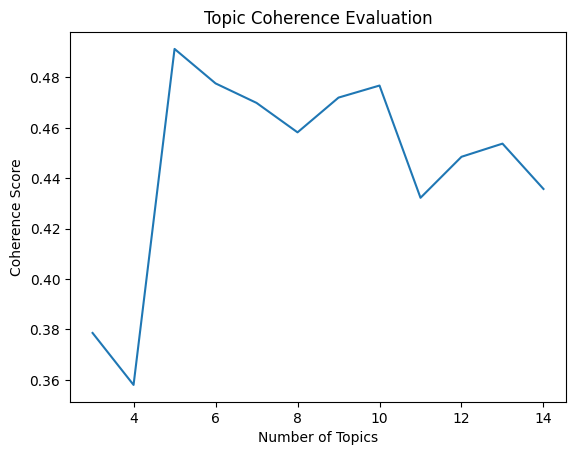


Best Number of Topics: 5
Best Coherence Score: 0.49129219167234695

Final LDA Model Saved


In [ ]:
# 1. Mount Drive
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# 2. Load Step 1 Outputs
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

print("Data loaded successfully!")
print("Dictionary size:", len(dictionary))
print("Number of documents:", len(corpus_bow))

# 3. Train Multiple LDA Models
coherence_scores = []
topic_range = range(3,15)

for num_topics in topic_range:

    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=5,
        chunksize=200,
        alpha='auto'
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts_bigrams,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

    print(f"Topics: {num_topics} | Coherence: {coherence:.4f}")

# 4. Plot Coherence
plt.figure()
plt.plot(topic_range, coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence Evaluation")
plt.show()

# 5. Best Topic Number
best_index = coherence_scores.index(max(coherence_scores))
best_num_topics = topic_range[best_index]

print("\nBest Number of Topics:", best_num_topics)
print("Best Coherence Score:", max(coherence_scores))

# 6. Train Final Model
final_lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=20,
    chunksize=200,
    alpha='auto',
    eta='auto'
)

# 7. Save Model
final_lda_model.save(load_path + "final_lda_model.gensim")

print("\nFinal LDA Model Saved")

In [ ]:
# STEP 3: TOPIC INTERPRETATION & ANALYSIS
# Mount Drive
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# Load components
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

final_lda_model = LdaModel.load(load_path + "final_lda_model.gensim")

print("Model and data loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and data loaded successfully


In [ ]:
import pandas as pd

num_words = 15
topics_data = []

for topic_id in range(final_lda_model.num_topics):

    words = final_lda_model.show_topic(topic_id, topn=num_words)
    word_list = [word for word, prob in words]

    topics_data.append({
        "Topic": f"Topic {topic_id+1}",
        "Top Keywords": ", ".join(word_list)
    })

topics_df = pd.DataFrame(topics_data)

print(topics_df)

     Topic                                       Top Keywords
0  Topic 1  social_medium, child, system, access, medical,...
1  Topic 2  nto, zkw, kznoytm, yoz, ltr, okwozmo, klwo, mk...
2  Topic 3  woman, order, child, death, pregnancy, materna...
3  Topic 4  student, nurse, hcws, fear, death, burnout, ho...
4  Topic 5  child, lockdown, item, depression_anxiety, anx...


In [ ]:
topics_df.to_excel("/content/drive/MyDrive/LDA_Project/topic_keywords_table.xlsx", index=False)

In [ ]:

# 2. Document-Topic Distribution


doc_topics = []

for doc in corpus_bow:
    topic_probs = final_lda_model.get_document_topics(doc)
    doc_topics.append(topic_probs)

# Convert to dataframe
topic_df = pd.DataFrame()

for i in range(final_lda_model.num_topics):
    topic_df[f"Topic_{i}"] = [
        dict(doc).get(i, 0) for doc in doc_topics
    ]

topic_df.head()

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4
0,0.822961,0.0,0.000000,0.107398,0.069483
1,0.838900,0.0,0.000000,0.150523,0.000000
2,0.450021,0.0,0.000000,0.459871,0.089998
3,0.685586,0.0,0.158246,0.116899,0.039248
4,0.571783,0.0,0.000000,0.315325,0.104360


In [ ]:
print(topic_df)

       Topic_0   Topic_1   Topic_2   Topic_3   Topic_4
0     0.822961  0.000000  0.000000  0.107398  0.069483
1     0.838900  0.000000  0.000000  0.150523  0.000000
2     0.450021  0.000000  0.000000  0.459871  0.089998
3     0.685586  0.000000  0.158246  0.116899  0.039248
4     0.571783  0.000000  0.000000  0.315325  0.104360
...        ...       ...       ...       ...       ...
1025  0.000000  0.000000  0.000000  0.999448  0.000000
1026  0.000000  0.999367  0.000000  0.000000  0.000000
1027  0.000000  0.000000  0.000000  0.000000  0.999535
1028  0.000000  0.000000  0.000000  0.000000  0.999230
1029  0.874402  0.000000  0.000000  0.125350  0.000000

[1030 rows x 5 columns]


In [ ]:
# Save document-topic distribution
topic_df.to_excel(load_path + "topic5_distribution.xlsx", index=False)

print("saved.")

saved.


In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(final_lda_model, corpus_bow, dictionary)
vis


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.109688 -0.001521       1        1  36.156492
4     -0.118871 -0.062958       2        1  35.676068
3     -0.120037 -0.160419       3        1  15.891325
2     -0.106152  0.230306       4        1   9.787696
1      0.454748 -0.005408       5        1   2.488420, topic_info=          Term         Freq        Total Category  logprob  loglift
1695   student  3563.000000  3563.000000  Default  30.0000  30.0000
296      nurse  2154.000000  2154.000000  Default  29.0000  29.0000
941      woman  1798.000000  1798.000000  Default  28.0000  28.0000
1003     child  4595.000000  4595.000000  Default  27.0000  27.0000
8231      hcws  1175.000000  1175.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
12733     vtzr    94.826435    95.607524   Topic5  -5.5145   3.6853
9759       tto    94.924927    95.713154   Topic5  -5.5135   3.6853
9783       zkt    91.807114    92.588203   Topic5  -5.5469   3.6851
9785   zkw_plo    90.350500    91.131591   Topic5  -5.5629   3.6849
14854      kwt    90.058265    90.839354   Topic5  -5.5661   3.6849

[354 rows x 6 columns], token_table=       Topic      Freq           Term
term                                 
16532      4  0.994354       abortion
9603       3  0.988183  academic_year
0          1  0.766912         access
0          2  0.035812         access
0          3  0.006757         access
...      ...       ...            ...
9780       5  0.994559          yozkw
9783       5  0.993647            zkt
9784       5  0.995271            zkw
9785       5  0.987583        zkw_plo
9791       5  0.993448            zto

[653 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 5, 4, 3, 2])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


perplexity & coherence

In [ ]:
import os

os.listdir("/content/drive/MyDrive/LDA_Project/")

['lda_corpus_tfidf.pkl',
 'lda_texts_bigrams.pkl',
 'lda_dictionary.gensim',
 'lda_corpus_bow.pkl',
 'document_topic_distribution.xlsx',
 'topic100_distribution.xlsx',
 'lda_visualization.html',
 'lda_visualization2.html',
 'topic_keywords_table.xlsx',
 'topic5_distribution.xlsx',
 'final_lda_model.gensim.expElogbeta.npy',
 'final_lda_model.gensim.state',
 'final_lda_model.gensim.id2word',
 'final_lda_model.gensim']

In [ ]:
# Install required libraries
!pip install gensim pyLDAvis

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Imports
import pickle
import os
from google.colab import drive
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 78.6 MB/s eta 0:00:00


In [ ]:
# STEP 3: TOPIC INTERPRETATION & ANALYSIS


# Mount Drive
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# Load components
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

final_lda_model = LdaModel.load(load_path + "final_lda_model.gensim")

print("Model and data loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and data loaded successfully


In [ ]:
import pandas as pd

num_words = 15
topics_data = []

for topic_id in range(final_lda_model.num_topics):

    words = final_lda_model.show_topic(topic_id, topn=num_words)
    word_list = [word for word, prob in words]

    topics_data.append({
        "Topic": f"Topic {topic_id+1}",
        "Top Keywords": ", ".join(word_list)
    })

topics_df = pd.DataFrame(topics_data)

print(topics_df)

     Topic                                       Top Keywords
0  Topic 1  social_medium, child, system, access, medical,...
1  Topic 2  nto, zkw, kznoytm, yoz, ltr, okwozmo, klwo, mk...
2  Topic 3  woman, order, child, death, pregnancy, materna...
3  Topic 4  student, nurse, hcws, fear, death, burnout, ho...
4  Topic 5  child, lockdown, item, depression_anxiety, anx...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data loaded successfully!


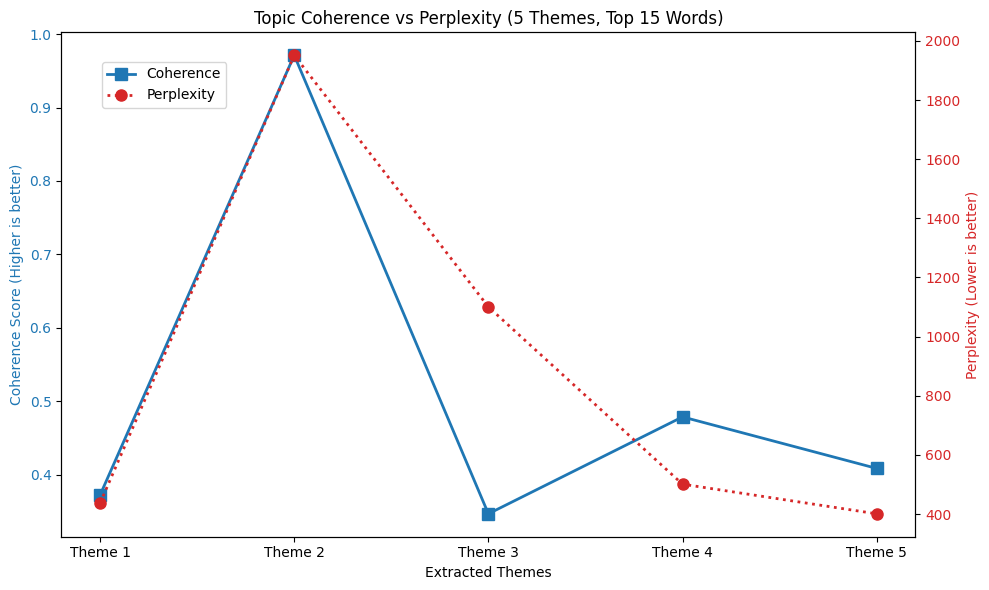


--- Metrics per Theme ---
Theme 1: Coherence = 0.3722, Perplexity = 437.20
Theme 2: Coherence = 0.9712, Perplexity = 1951.52
Theme 3: Coherence = 0.3466, Perplexity = 1100.70
Theme 4: Coherence = 0.4786, Perplexity = 501.09
Theme 5: Coherence = 0.4084, Perplexity = 400.92


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from google.colab import drive

# ---------------------------------------------------------
# 1. Mount Google Drive
# ---------------------------------------------------------
drive.mount('/content/drive')

# ---------------------------------------------------------
# 2. Define Path
# ---------------------------------------------------------
load_path = "/content/drive/MyDrive/LDA_Project/"

# ---------------------------------------------------------
# 3. Load Required Files
# ---------------------------------------------------------
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts = pickle.load(f)

lda_model = LdaModel.load(load_path + "final_lda_model.gensim")

print("✅ Data loaded successfully!")

# ---------------------------------------------------------
# 4. Parameters
# ---------------------------------------------------------
num_themes = 5
top_n_words = 15

# ---------------------------------------------------------
# 5. Coherence per Theme
# ---------------------------------------------------------
coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v',
    topn=top_n_words
)

coherence_per_theme = coherence_model.get_coherence_per_topic()

# ---------------------------------------------------------
# 6. Perplexity per Theme
# ---------------------------------------------------------
perplexity_per_theme = []

for theme_id in range(num_themes):
    theme_docs = []

    for doc in corpus:
        doc_topics = lda_model.get_document_topics(doc)
        if not doc_topics:
            continue

        dominant_topic = max(doc_topics, key=lambda x: x[1])[0]

        if dominant_topic == theme_id:
            theme_docs.append(doc)

    if theme_docs:
        log_perp = lda_model.log_perplexity(theme_docs)
        perplexity = np.exp2(-log_perp)
    else:
        perplexity = 0

    perplexity_per_theme.append(perplexity)

# ---------------------------------------------------------
# 7. Plot (UPDATED TO TWO LINE GRAPHS)
# ---------------------------------------------------------
themes = [f"Theme {i+1}" for i in range(num_themes)]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Coherence Line (Solid)
color1 = 'tab:blue'
ax1.set_xlabel('Extracted Themes')
ax1.set_ylabel('Coherence Score (Higher is better)', color=color1)
# Changed from ax1.bar to ax1.plot, added linestyle='solid' and markers
ax1.plot(themes, coherence_per_theme, color=color1, marker='s', linestyle='solid',
         linewidth=2, markersize=8, label='Coherence')
ax1.tick_params(axis='y', labelcolor=color1)

# Perplexity Line (Dotted)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Perplexity (Lower is better)', color=color2)
# Added linestyle='dotted' (can also use linestyle='--' for dashed)
ax2.plot(themes, perplexity_per_theme, color=color2, marker='o', linestyle='dotted',
         linewidth=2, markersize=8, label='Perplexity')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f'Topic Coherence vs Perplexity ({num_themes} Themes, Top {top_n_words} Words)')
fig.tight_layout()

# Combine legends
lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0], fig.axes[1]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.grid(False)
plt.show()

# ---------------------------------------------------------
# 8. Print Results
# ---------------------------------------------------------
print("\n--- Metrics per Theme ---")
for i in range(num_themes):
    print(f"Theme {i+1}: Coherence = {coherence_per_theme[i]:.4f}, Perplexity = {perplexity_per_theme[i]:.2f}")

MessageError: Error: credential propagation was unsuccessful